### Question to answer: What are the past and future projected distribution of OHCA incidence by location in Singapore? 

Outlining specific area on Google Map using GeoJson

https://www.geeksforgeeks.org/python/outline-specific-area-on-google-map-using-geojson/

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import io
import re
import math
import msoffcrypto
import re
import openpyxl

In [2]:
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box

In [3]:
# environment set up
from dotenv import load_dotenv
import os

# use os.getcwd instead of os.path.dirname(__file__) for jupyter notebooks to get the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))

load_dotenv(os.path.join(parent_dir, ".env"))

True

In [4]:
pd.set_option("display.max_columns", None)

DROPPED_CASES = 0

In [5]:
### Read the paros dataset
filename = "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"
# load password from .env
password = os.getenv("PAROS_PASSWORD")

with open("../../datasets/" + filename, "rb") as encrypted_data:
    paros = msoffcrypto.OfficeFile(encrypted_data)
    paros.load_key(password = password)
    # decrypt file into a BytesIO object
    decrypted = io.BytesIO()
    paros.decrypt(decrypted)

    # use pandas to read the decrypted Excel File
    df = pd.read_excel(decrypted)

/Users/yitong/opt/anaconda3/envs/geopandasNew/lib/python3.9/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Data Validation extension is not supported and will be removed
  for idx, row in parser.parse():


##### What are the percentage of OHCA case where location is unknown
This is for geospatial analysis

Filter for cases where:

- Location Unknown == "yes"


In [6]:
print("total cases in dataset:", df.shape[0])

total cases in dataset: 28665


In [7]:
## where Location of incident == N/A | blank
location_unknown = df[(df["Location of incident"].isnull())]
print("Number of cases with location unknown", location_unknown.shape[0])

## where Location of incident != N/A | blank
location_known = df[df["Location of incident"].notnull()]
print("Number of cases with known postal code", location_known.shape[0])

percentage_unknown = round((location_unknown.shape[0] / df.shape[0] * 100), 2)
print("percentage of cases with unknown location:", str(percentage_unknown) + "%")

Number of cases with location unknown 1038
Number of cases with known postal code 27627
percentage of cases with unknown location: 3.62%


#### Some of the location can be found in location type, will have to filter location_unknown to sieve them out later

Reducing the dataframes to the more important columns. Easier to work with

In [8]:
impt_columns = ["Case #", "Site #", "Date of Incident", "Location of incident", "Location Unknown",
                "Location Type", "Location Type Other", "Time call received at dispatch center",
                "Estimated time of arrest"]

postal_code_known = location_known[impt_columns].copy()

# does not mean location is not given
no_postal_code = location_unknown[impt_columns].copy()

# print(no_postal_code)

In [9]:
# export the 2 dataframes into xlsx files
output_path = "../../datasets/"
postal_filename = output_path + "1known_postal.xlsx"
no_postal_filename = output_path + "1unknown_postal.xlsx"

postal_code_known.to_excel(postal_filename)
no_postal_code.to_excel(no_postal_filename)

Some entries without postal code can still provide some information on the location.

First create another dataframe without rows that does not provide any location information

In [66]:
# remove rows where Location Type Other is null or Blank
modified_no_postal_code = no_postal_code.copy()
# remove whitespaces
modified_no_postal_code["Location Type Other"] = modified_no_postal_code["Location Type Other"].str.strip()
print(modified_no_postal_code.count())
no_postal_code_count = modified_no_postal_code.shape[0]
print("Total:", no_postal_code_count)
modified_no_postal_code["Location Type Other"] = modified_no_postal_code["Location Type Other"].replace('', np.nan)

# drop nan values
modified_no_postal_code.dropna(subset = ["Location Type Other"], inplace = True)
print("\nAfter dropping empty rows in Location Type Other:\n", modified_no_postal_code.count())
remaining_no_postal_code_count = modified_no_postal_code.shape[0]
print("After dropping empty rows:", remaining_no_postal_code_count)

DROPPED_CASES = no_postal_code_count - remaining_no_postal_code_count
print("Dropped cases:", DROPPED_CASES)


Case #                                   1038
Site #                                   1038
Date of Incident                         1038
Location of incident                        0
Location Unknown                         1032
Location Type                            1038
Location Type Other                       460
Time call received at dispatch center     837
Estimated time of arrest                  937
dtype: int64
Total: 1038

After dropping empty rows in Location Type Other:
 Case #                                   419
Site #                                   419
Date of Incident                         419
Location of incident                       0
Location Unknown                         419
Location Type                            419
Location Type Other                      419
Time call received at dispatch center    318
Estimated time of arrest                 366
dtype: int64
After dropping empty rows: 419
Dropped cases: 619


Now to remove rows that only has "level xx" as this does not provide any information

In [67]:
remaining_no_postal_code_count = modified_no_postal_code.shape[0]
# remove rows where Location Type Other == "level 1" or anything similar

# remove rows where there is only one or 2 words word in Location Type Other
mask = (
    modified_no_postal_code["Location Type Other"].str.strip().str.count(r'\s') <= 2
)
modified_no_postal_code = modified_no_postal_code[~mask]

mask_2 = (
    modified_no_postal_code['Location Type Other']
    .fillna('')                           # Handle NaNs
    .str.lower()                          # Make comparison case-insensitive
    .str.contains(r'\bin\b')             # Word boundary to match 'in' as a word
    # & modified_no_postal_code['Location Type Other']
    # .fillna('')
    # .str.lower()
    # .str.contains(r'\bcar\b')             # Match 'car' as a word
)
modified_no_postal_code = modified_no_postal_code[~mask_2]

modified_no_postal_code['Location Type Other'] = (
    modified_no_postal_code['Location Type Other']
    .fillna('')  # Handle NaNs
    .str.replace(r'(?i)\b(level|lvl)\s*\d+\b', '', regex=True)  # Remove Level/Lvl + number
    .str.replace(r'\(\s*\)', '', regex=True)  # Remove empty parentheses left behind
    .str.replace(r'\s{2,}', ' ', regex=True)  # Clean up extra spaces
    .str.strip()  # Final trim
)

print(modified_no_postal_code, "\n")
final_no_postal_code_count = modified_no_postal_code.shape[0]
print("After dropping addresses with 'level xx':", final_no_postal_code_count)
DROPPED_CASES += remaining_no_postal_code_count - final_no_postal_code_count
print("Total removed cases:", DROPPED_CASES)

filename = output_path + "1unknown_postal_modified.xlsx"
modified_no_postal_code.to_excel(filename)

             Case #  Site # Date of Incident  Location of incident  \
296     SGSIN054898       5       2010-06-18                   NaN   
373      SGSIN07823       7       2010-07-10                   NaN   
524           61197       6       2010-08-18                   NaN   
550     SGSIN015004       1       2010-08-25                   NaN   
631      SGSIN07643       7       2010-09-13                   NaN   
...             ...     ...              ...                   ...   
11929  SGSIN0127969       1       2016-10-03                   NaN   
11976  SGSIN0526982       5       2016-10-09                   NaN   
12092  SGSIN0227361       2       2016-10-26                   NaN   
12287  SGSIN0629661       6       2016-11-22                   NaN   
12378  SGSIN0529639       5       2016-12-05                   NaN   

      Location Unknown             Location Type  \
296                Yes              Nursing Home   
373                Yes  In EMS/Private ambulance   
524

In [54]:
print("Total number of OHCA cases dropped so far:", DROPPED_CASES)

Total number of OHCA cases dropped so far: 900


In [12]:
## get unique postal code from the dataset, reduce the number of queries to Google API
## split the postal codes into smaller chunks for easier convertion from postal code to geolocation
output_path = "../../datasets/"
base_filename = "postal_code_part"
num_parts = 1
postal_code_known["Location of incident"] = postal_code_known["Location of incident"].astype(int)
unique_postal_code = pd.DataFrame(postal_code_known["Location of incident"].unique(), columns = ["postal code"])

chunk_size = math.ceil(len(unique_postal_code) / num_parts)
print(chunk_size)
for i in range(num_parts):
    start_idx = i * chunk_size
    end_idx = start_idx + chunk_size
    chunk = unique_postal_code.iloc[start_idx:end_idx]
    
    chunk_filename = f"{output_path}{base_filename}_{i+1}.csv"
    chunk.to_csv(chunk_filename, index=False)
    print(f"Saved: {chunk_filename} ({len(chunk)} rows)")

# unique_postal_code.to_csv(output_path, index = False)
# print(unique_postal_code)


13009
Saved: ../../datasets/postal_code_part_1.csv (13009 rows)


Conversion of addresses (postal code or description) is done by the postal_to_coordinates.py file

Map postal code / addresses to their coordinates.

Get the coordinates for the unknown postal codes first

In [ ]:
# If coordinates of addresses has been obtained, don't run this code. This code is not dynamic enough
# filename = "2unknown_postal_modified_final.xlsx"
# filepath = "../../datasets/" + filename
# coordinates_unknown_postal = pd.read_excel(filepath, sheet_name = 0)
# # drop rows where lat and long is not known 
# coordinates_unknown_postal.dropna(axis = "index", 
#                                   subset = ["lat", "lon"], 
#                                   inplace = True)
# coordinates_unknown_postal.drop(["Address"], axis = "columns", inplace = True)
# print(coordinates_unknown_postal.count())

Unnamed: 0              105
Case #                  105
Site #                  105
Date of Incident        105
Location of incident      0
Location Unknown        105
Location Type           105
Location Type Other     105
lat                     105
lon                     105
dtype: int64


Map the addresses to their coordinates and drop the ones not known

In [76]:
from rapidfuzz import fuzz, process

# google map api seems to change the Address column slightly when you use it to obtain lat and long
# using similarity threshold to merge the addresses with coordinates
# threshold for match similarity, just an estimation
SIMILARITY_THRESHOLD = 60

# Create a function to match each unknown address to the best match
def get_best_match(row, choices, threshold=SIMILARITY_THRESHOLD):
    match, score, _ = process.extractOne(
        row['Location Type Other'],
        choices,
        scorer=fuzz.token_sort_ratio
    )
    if score >= threshold:
        return match
    return None


filename = "1unknown_postal_modified.xlsx"
filepath = "../../datasets/" + filename

unknown_postal_df = pd.read_excel(filepath, sheet_name = 0)

filename_2 = "2unknown_postal_to_coordinate_results.xlsx"
filepath_2 = "../../datasets/" + filename_2
address_to_coordinate_conversion = pd.read_excel(filepath_2, sheet_name = 0)

# rename column name to match that of the PAROS dataset
address_to_coordinate_conversion.rename(columns = {"Address": "Location Type Other"}, inplace = True)

# Ensure text columns are strings and NaNs handled
unknown_postal_df['Location Type Other'] = unknown_postal_df['Location Type Other'].fillna('').astype(str)
address_to_coordinate_conversion['Location Type Other'] = address_to_coordinate_conversion['Location Type Other'].fillna('').astype(str)

# Get unique choices from the reference dataframe
reference_choices = address_to_coordinate_conversion['Location Type Other'].unique()

# Create matched_location column using fuzzy match
unknown_postal_df['matched_location'] = unknown_postal_df.apply(
    lambda row: get_best_match(row, reference_choices), axis=1
)

# merged_postal_code_unknown = unknown_postal_df.merge(address_to_coordinate_conversion[['Location Type Other', 'lat', 'lon']],
#                                     on='Location Type Other',
#                                     how='left')

merged_df = unknown_postal_df.merge(
    address_to_coordinate_conversion[['Location Type Other', 'lat', 'lon']],
    left_on='matched_location',
    right_on='Location Type Other',
    how='left'
)

# Drop intermediate columns if needed
merged_df.drop(columns=['matched_location'], inplace=True)

print(merged_df.count())
merged_df.to_excel("../../datasets/2unknown_postal_modified_final.xlsx")
# print(merged_postal_code_unknown)



Unnamed: 0                               138
Case #                                   138
Site #                                   138
Date of Incident                         138
Location of incident                       0
Location Unknown                         138
Location Type                            138
Location Type Other_x                    138
Time call received at dispatch center    130
Estimated time of arrest                 131
Location Type Other_y                    129
lat                                      102
lon                                      102
dtype: int64


In [81]:
# get the address to coordinates conversion excel sheet for the addresses with no postal code
filename = "2unknown_postal_modified_final.xlsx"
filepath = "../../datasets/" + filename

coordinates_unknown_postal = pd.read_excel(filepath, sheet_name = 0)
# drop rows where lat and long is not known 
before_dropping = coordinates_unknown_postal.shape[0]
print(before_dropping, "\n")
coordinates_unknown_postal.dropna(axis = "index", 
                                  subset = ["lat", "lon"], 
                                  inplace = True)
# coordinates_unknown_postal.drop(["Address"], axis = "columns", inplace = True)
print("After dropping rows with no lat or long:")
after_dropping = coordinates_unknown_postal.shape[0]
print(after_dropping)

DROPPED_CASES += before_dropping - after_dropping
print("Total dropped cases:", DROPPED_CASES)

138 

After dropping rows with no lat or long:
102
Total dropped cases: 936


Now for the OHCA cases where postal code is known

I want to map location of incident column in the PAROS dataset to the postal code column in 2postal_to_coordinates_conversion_final.xlsx

In [82]:
filename = "2postal_to_coordinates_conversion_final.xlsx"
filepath = "../../datasets/" + filename

postal_coords_df = pd.read_excel(filepath, sheet_name = 0)
# rename column name to match that of the PAROS dataset
postal_coords_df.rename(columns = {"postal code": "Location of incident"}, inplace = True)

# print(postal_coords_df["postal code"].head())
postal_code_known["Location of incident"] = postal_code_known["Location of incident"].astype(np.int64)
# print(postal_code_known["Location of incident"].head())

## merge postal_coords_df into postal_code_known on the "Location of incident" column
merged_postal_code_known = postal_code_known.merge(postal_coords_df[['Location of incident', 'lat', 'lon']],
                                    on='Location of incident',
                                    how='left')

print(merged_postal_code_known.count())

Case #                                   27627
Site #                                   27627
Date of Incident                         27627
Location of incident                     27627
Location Unknown                             2
Location Type                            27627
Location Type Other                      12086
Time call received at dispatch center    27533
Estimated time of arrest                 27542
lat                                      27627
lon                                      27627
dtype: int64


Now merging the two dataframes, one where postal code is known and one where postal code is **not** known. Output into excel file.

We will also remove coordinates that are outside of Singapore

In [83]:
## now merge the 2 dataframes
final_df = pd.concat([merged_postal_code_known, coordinates_unknown_postal],
                     ignore_index = True)

# Final step, remove invalid coordinates due to google api returning the wrong answer
valid_lat_min = 1.18
valid_lat_max = 1.48
valid_lon_min = 103.6
valid_lon_max = 104.1
# Filter DataFrame
filtered_final_df = final_df[
    (final_df['lat'] >= valid_lat_min) & (final_df['lat'] <= valid_lat_max) &
    (final_df['lon'] >= valid_lon_min) & (final_df['lon'] <= valid_lon_max)
].copy()


print(filtered_final_df.count())
filtered_final_df.to_excel("../../datasets/3_OHCA_with_coords.xlsx")

Case #                                   27729
Site #                                   27729
Date of Incident                         27729
Location of incident                     27627
Location Unknown                           104
Location Type                            27729
Location Type Other                      12086
Time call received at dispatch center    27632
Estimated time of arrest                 27640
lat                                      27729
lon                                      27729
Unnamed: 0.1                               102
Unnamed: 0                                 102
Location Type Other_x                      102
Location Type Other_y                      102
dtype: int64


#### We started with 28665 total cases. 27729 cases were able to be mapped to coordinates.

Moving on to plot the OHCA cases onto Singapore's map

In [51]:
filename = "3_OHCA_with_coords.xlsx"
filepath = "../../datasets/" + filename
postal_code_df = pd.read_excel(filepath, sheet_name = 0)
# drop unneeded columns 
postal_code_df.drop(["Location Unknown", "Location Type",
                     "Location Type Other", "Unnamed: 0"],
                     axis = "columns", inplace = True)
print(postal_code_df.head())

   Unnamed: 0.2     Case #  Site # Date of Incident  Location of incident  \
0             0  SGSIN0213       2       2010-04-01              470146.0   
1             1  SGSIN0218       2       2010-04-01              520926.0   
2             2  SGSIN6480       6       2010-04-01              560565.0   
3             3  SGSIN5332       5       2010-04-02              680626.0   
4             4  SGSIN0214       2       2010-04-03              468963.0   

  Time call received at dispatch center Estimated time of arrest       lat  \
0                              23:29:17                 23:35:00  1.334604   
1                              14:18:54                 14:05:00  1.346122   
2                              16:35:03                 16:30:00  1.369882   
3                              02:28:08                 02:00:00  1.398315   
4                              08:56:21                 09:00:00  1.315317   

          lon  Unnamed: 0.1 Location Type Other_x Location Type Othe

In [54]:
print(postal_code_df.shape[0])
# check for duplicated values
duplicate_values = postal_code_df.loc[postal_code_df["Case #"].duplicated(), "Case #"]
print(duplicate_values)

27729
Series([], Name: Case #, dtype: object)


In [17]:
# turn the longitude and latitude into coordinates
postal_code_df["Coordinates"] = gpd.points_from_xy(postal_code_df["lon"], postal_code_df["lat"])
# turn the coordinates tuple into a shapely point object
locations_gdf = gpd.GeoDataFrame(
    postal_code_df.dropna(subset = ["lat", "lon"]),
    geometry = "Coordinates",
    crs = "EPSG:4326",
)

print(locations_gdf.shape[0])
print(locations_gdf.head())
print('gdf is of type:', type(locations_gdf), "\ncrs is:", locations_gdf.crs)
print('\nThe geometry column is:', locations_gdf.geometry.name)


print("Raw CRS :", locations_gdf.crs)              # what the file *claims*
print("Raw bounds :", locations_gdf.total_bounds)



27729
   Unnamed: 0.2     Case #  Site # Date of Incident  Location of incident  \
0             0  SGSIN0213       2       2010-04-01              470146.0   
1             1  SGSIN0218       2       2010-04-01              520926.0   
2             2  SGSIN6480       6       2010-04-01              560565.0   
3             3  SGSIN5332       5       2010-04-02              680626.0   
4             4  SGSIN0214       2       2010-04-03              468963.0   

  Time call received at dispatch center Estimated time of arrest       lat  \
0                              23:29:17                 23:35:00  1.334604   
1                              14:18:54                 14:05:00  1.346122   
2                              16:35:03                 16:30:00  1.369882   
3                              02:28:08                 02:00:00  1.398315   
4                              08:56:21                 09:00:00  1.315317   

          lon  Unnamed: 0.1 Location Type Other_x Location Typ

In [18]:
import time
from geopy.geocoders import Nominatim


https://colab.research.google.com/github/QuantEcon/quantecon-notebooks-datascience/blob/master/applications/maps.ipynb#scrollTo=4xSATFfrY0Je

In [19]:
sg_map = "../../dr_sean_code/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson"

sg_gdf = gpd.read_file(sg_map)
# sg_gdf = sg_raw.set_crs(epsg=3414, allow_override=True)
# sg_gdf = sg_gdf.to_crs(epsg=4326)

print(sg_gdf.crs)

EPSG:4326


In [88]:
sg_gdf["Description"][0]

'<center><table><tr><th colspan=\'2\' align=\'center\'><em>Attributes</em></th></tr><tr bgcolor="#E3E3F3"> <th>SUBZONE_NO</th> <td>12</td> </tr><tr bgcolor=""> <th>SUBZONE_N</th> <td>DEPOT ROAD</td> </tr><tr bgcolor="#E3E3F3"> <th>SUBZONE_C</th> <td>BMSZ12</td> </tr><tr bgcolor=""> <th>CA_IND</th> <td>N</td> </tr><tr bgcolor="#E3E3F3"> <th>PLN_AREA_N</th> <td>BUKIT MERAH</td> </tr><tr bgcolor=""> <th>PLN_AREA_C</th> <td>BM</td> </tr><tr bgcolor="#E3E3F3"> <th>REGION_N</th> <td>CENTRAL REGION</td> </tr><tr bgcolor=""> <th>REGION_C</th> <td>CR</td> </tr><tr bgcolor="#E3E3F3"> <th>INC_CRC</th> <td>C22DED671DE2A940</td> </tr><tr bgcolor=""> <th>FMEL_UPD_D</th> <td>20191223152313</td> </tr></table></center>'

In [ ]:
# Extract planning area and subzone from each Description
subzones = []
planning_areas = []

# Loop through each row of the GeoDataFrame
for description in sg_gdf['Description']:
    subzone_match = re.search(r"<th>SUBZONE_N</th>\s*<td>(.*?)</td>", description)
    planning_area_match = re.search(r"<th>PLN_AREA_N</th>\s*<td>(.*?)</td>", description)

    subzones.append(subzone_match.group(1) if subzone_match else None)
    planning_areas.append(planning_area_match.group(1) if planning_area_match else None)

# Add new columns to the GeoDataFrame
sg_gdf['SUBZONE_N'] = subzones
sg_gdf['PLN_AREA_N'] = planning_areas

print(sg_gdf.crs)

EPSG:4326


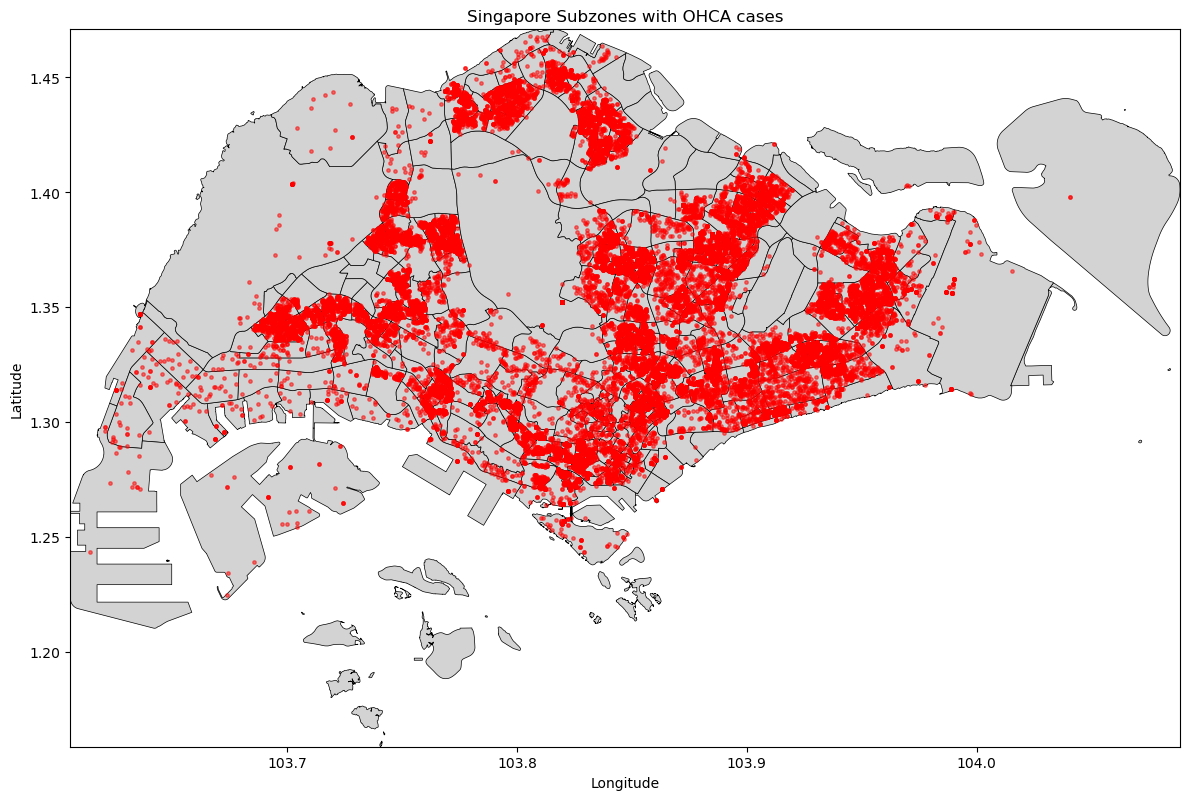

In [ ]:
# sg_gdf = sg_gdf.to_crs(epsg = 3414)

# if locations_gdf.crs is None:
#     locations_gdf.set_crs(epsg=3414, inplace=True)
# else:
#     locations_gdf = locations_gdf.to_crs(epsg=3414)

if sg_gdf.crs is None:
    sg_gdf = sg_gdf.set_crs("EPSG:4326")
if locations_gdf.crs is None:
    locations_gdf = locations_gdf.set_crs("EPSG:4326")

if sg_gdf.crs != locations_gdf.crs:
    locations_gdf = locations_gdf.to_crs(sg_gdf.crs)


fig, ax = plt.subplots(figsize=(12, 10))
sg_gdf.plot(ax=ax, edgecolor="black", facecolor="lightgray", linewidth=0.5)
locations_gdf.plot(ax=ax, color="red", alpha=0.5, markersize=6)

# lock limits to the map's bounds, ignoring outliers
minx, miny, maxx, maxy = sg_gdf.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
# keep the map from looking squashed
ax.set_aspect("equal")

ax.set_title("Singapore Subzones with OHCA cases")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

Visualising with choropleths

     PLN_AREA_N               SUBZONE_N  OHCA_count
0    ANG MO KIO  ANG MO KIO TOWN CENTRE          66
1    ANG MO KIO               CHENG SAN         218
2    ANG MO KIO              CHONG BOON         221
3    ANG MO KIO             KEBUN BAHRU         165
4    ANG MO KIO         SEMBAWANG HILLS          37
..          ...                     ...         ...
303      YISHUN          YISHUN CENTRAL          25
304      YISHUN             YISHUN EAST         231
305      YISHUN            YISHUN SOUTH         274
306      YISHUN             YISHUN WEST         430
307         NaN                     NaN           2

[308 rows x 3 columns]


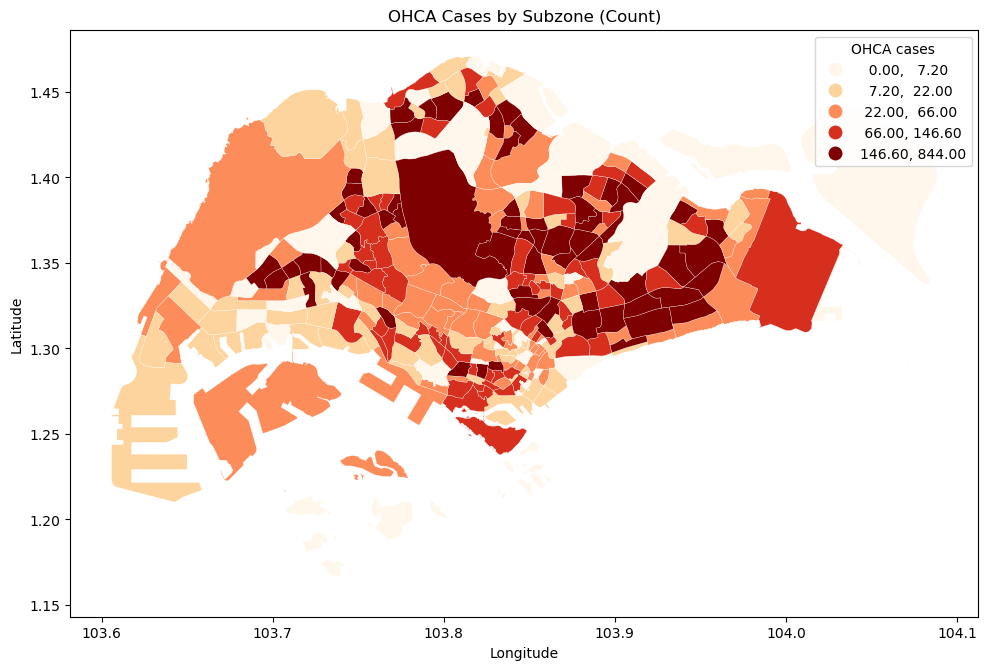

In [ ]:
# spatial join: tag each OHCA point with its subzone/ planning area
poly_cols = ["PLN_AREA_N", "SUBZONE_N", "geometry"]
pts_in_poly = gpd.sjoin(
    locations_gdf,
    sg_gdf[poly_cols],
    how = "left",
    predicate = "within",
)

# count OHCA per subzone
counts = (
    pts_in_poly.groupby(["PLN_AREA_N", "SUBZONE_N"], 
                        dropna = False).size()
                        .reset_index(name = "OHCA_count")
)
# print(counts)

# merge counts back to polygons; fill missing with 0
sg_counts = sg_gdf.merge(counts, on = ["PLN_AREA_N", "SUBZONE_N"], how = "left")
sg_counts["OHCA_count"] = sg_counts["OHCA_count"].fillna(0).astype(int)


fig, ax = plt.subplots(figsize=(10, 8))
sg_counts.plot(
    ax=ax,
    column="OHCA_count",
    cmap="OrRd",
    scheme="quantiles",  # nice balanced buckets
    k=5,
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    legend_kwds={"title": "OHCA cases"}
)
ax.set_title("OHCA Cases by Subzone (Count)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


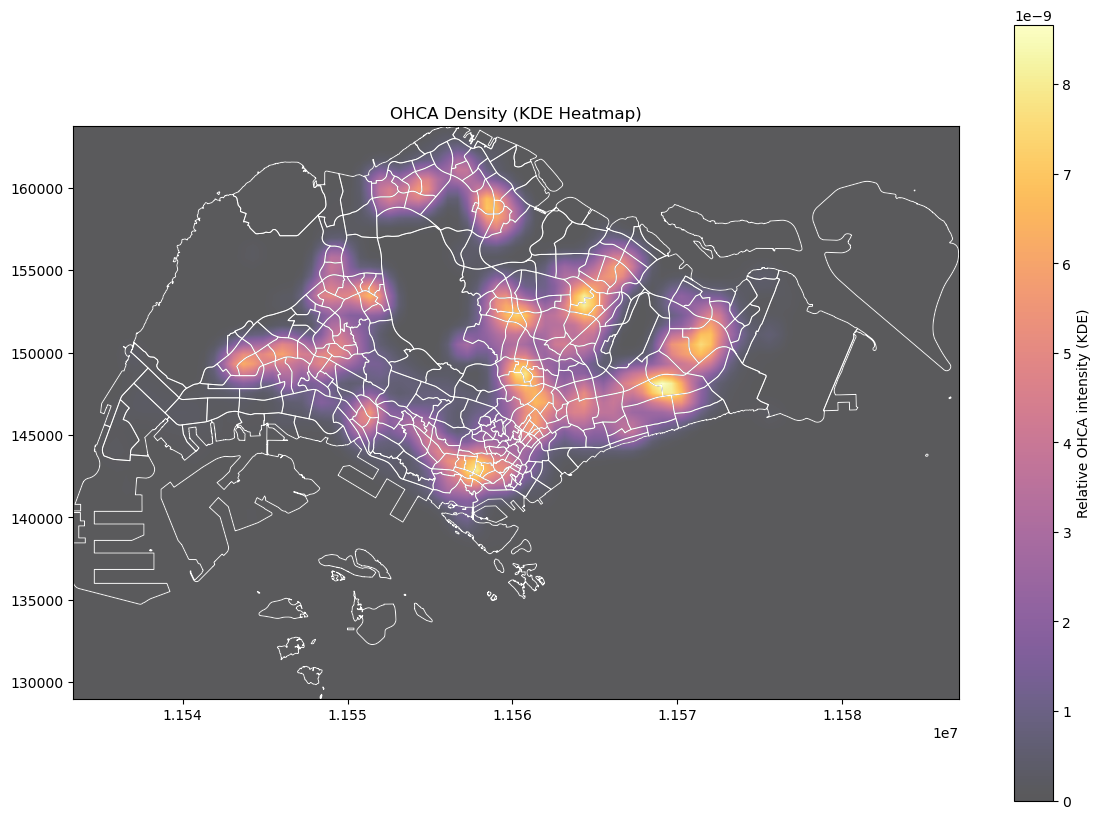

In [43]:
from sklearn.neighbors import KernelDensity

# Work in a metric CRS (meters) for bandwidths and grid size
sg_3857   = sg_gdf.to_crs(3857)
pts_3857  = locations_gdf.to_crs(3857)

# Build a grid over Singapore’s bounds (tweak cell size for resolution)
minx, miny, maxx, maxy = sg_3857.total_bounds
cell = 600  # grid cell size in meters (smaller = sharper, larger = smoother)
xs = np.arange(minx, maxx + cell, cell)
ys = np.arange(miny, maxy + cell, cell)
xx, yy = np.meshgrid(xs, ys)
grid = np.column_stack([xx.ravel(), yy.ravel()])

# Fit KDE to the points (bandwidth controls smoothness)
coords = np.column_stack([pts_3857.geometry.x, pts_3857.geometry.y])
kde = KernelDensity(bandwidth=600, kernel="gaussian")  # try 300–1000 m
kde.fit(coords)
log_dens = kde.score_samples(grid)
dens = np.exp(log_dens).reshape(xx.shape)

# Plot boundary + heat surface overlay
fig, ax = plt.subplots(figsize=(12, 10))
# base map: subzone outlines for context
sg_3857.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.5)

# heat layer (continuous choropleth)
im = ax.imshow(
    dens,
    origin="lower",
    extent=(minx, maxx, miny, maxy),
    cmap="inferno",
    alpha=0.65,    # transparency so map shows through
    interpolation="bilinear",  # soften pixels
)

sg_3857.boundary.plot(ax=ax, color="white", linewidth=0.7)

# colorbar + cosmetics
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Relative OHCA intensity (KDE)")
ax.set_title("OHCA Density (KDE Heatmap)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()